_© 2025–2026 Ibrahim Malik. Released under the MIT License (see LICENSE)._

# 02 · Modelling and Evaluation

1) **Baselines** (LogReg for abandonment; Decision Tree for reason)  
2) **Time-aware CV & thresholding** (best-F1, calibration)  
3) **Refinements** (XGB/HistGB; Random Forest)  

> Datasets: Modelling table `ready_for_ml.csv` produced in [01 · Data Prep](notebooks/01_data_preparation.ipynb) from Austin Animal Center Intakes & Outcomes.

_Ibrahim Malik, September 2025_ 



In [1]:
# Imports

import collections
import json
import logging
import os
import re
import sys
import time
import traceback

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import collections

# parent dir
sys.path.insert(0, os.path.abspath(".."))

from joblib import dump
from scipy.special import expit

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Importing specific functions from this module
from src.data_preprocessing import parse_age_to_days

In [2]:
# Progress helpers

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("model")  # or "kennel.ops" to match 01

RUN_ID = time.strftime("%Y%m%d-%H%M%S")
log.info("run_id=%s", RUN_ID)

def timeit(msg: str):
    log.info("▶ %s", msg)
    t0 = time.perf_counter()
    def done():
        dt = time.perf_counter() - t0
        log.info("✓ %s (%.1fs)", msg, dt)
    return done

def safe_fit(est, X, y, label="model"):
    log.info("… fitting %s on X=%s, y=%d", label, getattr(X, "shape", None), len(y))
    try:
        est.fit(X, y)
    except Exception:
        log.exception("Error while fitting %s", label)  # includes traceback
        raise
    log.info("✓ fit %s", label)
    return est

INFO: run_id=20250828-183625


In [3]:
# Paths

PROC_DIR = "../data/processed"
DOCS_DIR = "../docs"
FIG_DIR = "../figures"
MODELS_DIR = "../models"
os.makedirs(DOCS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [4]:
# Load modelling table/data

df = pd.read_csv(
    f"{PROC_DIR}/ready_for_ml.csv",
    parse_dates=["match_time_intake","match_time_outcome","next_intake_time"]
)
log.info("Loaded dataset: %s", df.shape)

INFO: Loaded dataset: (94608, 12)


In [5]:
# Feature engineering

# Feature engineering: age (days)
df["age_days_intake"] = pd.to_numeric(
    df["age_upon_intake_intake"].apply(parse_age_to_days),
    errors="coerce"  # None/invalid to NaN
)

# Feature lists
num_feats = ["age_days_intake"]
cat_feats = ["intake_type_intake","intake_condition_intake",
             "sex_upon_intake_intake","breed_intake","color_intake"]

# Drop rows missing labels
bin_df = df.dropna(subset=["abandoned_365","match_time_intake"]).copy()
mc_df  = df.dropna(subset=["abandon_reason","match_time_intake"]).copy()
log.info("Binary rows: %d | Multi-class rows: %d", len(bin_df), len(mc_df))

# Chronological split (80/20 by intake time)
def chrono_split(d, time_col, frac=0.8):
    d = d.sort_values(time_col)
    cut = int(len(d)*frac)
    return d.iloc[:cut], d.iloc[cut:]

bin_train, bin_test = chrono_split(bin_df, "match_time_intake", 0.8)
mc_train,  mc_test  = chrono_split(mc_df,  "match_time_intake", 0.8)
log.info(
    "Chrono split — binary train/test = %d/%d | multi-class train/test = %d/%d",
    len(bin_train), len(bin_test), len(mc_train), len(mc_test)
)

INFO: Binary rows: 94608 | Multi-class rows: 94608
INFO: Chrono split — binary train/test = 75686/18922 | multi-class train/test = 75686/18922


In [6]:
# preprocessor factory
# Fresh instance per pipeline

def make_pre():
    try:
        return ColumnTransformer([
            ("num", "passthrough", num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat_feats)
        ])
    except TypeError:
        log.warning("OneHotEncoder.min_frequency not supported; using default.")
        return ColumnTransformer([
            ("num", "passthrough", num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
        ])

## Baselines

Baselines and separate preprocessors and save TRAIN_INPUT_COLS + metrics + model

INFO: Training LogisticRegression (binary)…
INFO: ▶ LogisticRegression fit
INFO: … fitting LogReg pipeline on X=(75686, 6), y=75686
C:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
INFO: ✓ fit LogReg pipeline
INFO: ✓ LogisticRegression fit (1.5s)
INFO: TRAIN_INPUT_COLS: ['age_days_intake', 'intake_type_intake', 'intake_condition_intake', 'sex_upon_intake_intake', 'breed_intake', 'color_intake']
INFO: [Binary baseline] PR-AUC=0.099 | @0.5: F1=0.149 P=0.087 R=0.536
INFO: [Binary baseline] Best-F1 threshold ≈ 0.580 -> F1=0.159, P=0.109, R=0.291

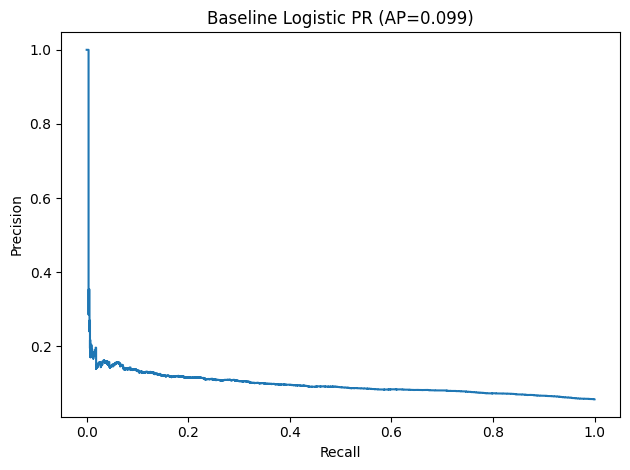

INFO: Saved -> ../docs/metrics_baseline.json and ../models/baseline_bin_clf.joblib


In [7]:
# Binary: Logistic Regression
log.info("Training LogisticRegression (binary)…")
X_tr = bin_train[num_feats + cat_feats]; y_tr = bin_train["abandoned_365"].astype(int)
X_te = bin_test[num_feats + cat_feats];  y_te = bin_test["abandoned_365"].astype(int)

pre_bin = make_pre()
bin_clf = Pipeline([
    ("pre", pre_bin),
    ("clf", LogisticRegression(max_iter=200, class_weight="balanced"))
])

done = timeit("LogisticRegression fit")
bin_clf = safe_fit(bin_clf, X_tr, y_tr, label="LogReg pipeline")
done()

# Save exact raw training columns for inference schema
TRAIN_INPUT_COLS = (num_feats + cat_feats).copy()
log.info("TRAIN_INPUT_COLS: %s", TRAIN_INPUT_COLS)
with open(f"{MODELS_DIR}/train_input_cols.json","w") as f:
    json.dump(TRAIN_INPUT_COLS, f)

# Evaluate
proba = bin_clf.predict_proba(X_te)[:, 1]
pred05 = (proba >= 0.5).astype(int)

bin_ap  = float(average_precision_score(y_te, proba))
bin_f1  = float(f1_score(y_te, pred05))
bin_pr  = float(precision_score(y_te, pred05, zero_division=0))
bin_rec = float(recall_score(y_te, pred05, zero_division=0))
log.info("[Binary baseline] PR-AUC=%.3f | @0.5: F1=%.3f P=%.3f R=%.3f", bin_ap, bin_f1, bin_pr, bin_rec)

# Best-F1 threshold sweep
precision, recall, thresholds = precision_recall_curve(y_te, proba)
thr_all = np.concatenate(([0], thresholds))
f1s = 2 * (precision * recall) / (precision + recall + 1e-12)
best_idx = int(np.nanargmax(f1s))
best_thr, best_f1, p_at, r_at = float(thr_all[best_idx]), float(f1s[best_idx]), float(precision[best_idx]), float(recall[best_idx])
log.info("[Binary baseline] Best-F1 threshold ≈ %.3f -> F1=%.3f, P=%.3f, R=%.3f", best_thr, best_f1, p_at, r_at)

# PR curve
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Baseline Logistic PR (AP={bin_ap:.3f})")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/pr_curve_binary.png", bbox_inches="tight")
plt.show()

# Save baseline metrics and model
metrics = {
    "binary": {
        "pr_auc": bin_ap, "f1": bin_f1, "precision": bin_pr, "recall": bin_rec,
        "best_threshold": best_thr, "best_threshold_f1": best_f1,
        "best_threshold_precision": p_at, "best_threshold_recall": r_at
    }
}
with open(f"{DOCS_DIR}/metrics_baseline.json","w") as f:
    json.dump(metrics, f, indent=2)
dump(bin_clf, f"{MODELS_DIR}/baseline_bin_clf.joblib")
log.info("Saved -> %s and %s", f"{DOCS_DIR}/metrics_baseline.json", f"{MODELS_DIR}/baseline_bin_clf.joblib")

In [8]:
# Multiclass: Decision Tree
log.info("Training DecisionTree (multi-class)…")
mc_sub = mc_train[mc_train["abandon_reason"]!="no_return"].copy()  # model reason only when a return exists
mc_te2 = mc_test[mc_test["abandon_reason"]!="no_return"].copy()

X_tr_m = mc_sub[num_feats + cat_feats]; y_tr_m = mc_sub["abandon_reason"].astype(str)
X_te_m = mc_te2[num_feats + cat_feats]; y_te_m = mc_te2["abandon_reason"].astype(str)

pre_mc = make_pre()
mc_clf = Pipeline([
    ("pre", pre_mc),
    ("clf", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42))
])

done = timeit("DecisionTree fit")
mc_clf = safe_fit(mc_clf, X_tr_m, y_tr_m, label="DecisionTree pipeline")
done()

y_hat_m = mc_clf.predict(X_te_m)
mc_acc = float(accuracy_score(y_te_m, y_hat_m))
mc_f1  = float(f1_score(y_te_m, y_hat_m, average="macro"))
log.info("[Multiclass baseline] Acc=%.3f  Macro-F1=%.3f", mc_acc, mc_f1)

with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    m = json.load(f)
m["multiclass"] = {"accuracy": mc_acc, "macro_f1": mc_f1}
with open(f"{DOCS_DIR}/metrics_baseline.json","w") as f:
    json.dump(m, f, indent=2)
log.info("Updated -> %s", f"{DOCS_DIR}/metrics_baseline.json")

INFO: Training DecisionTree (multi-class)…
INFO: ▶ DecisionTree fit
INFO: … fitting DecisionTree pipeline on X=(10259, 6), y=10259
INFO: ✓ fit DecisionTree pipeline
INFO: ✓ DecisionTree fit (0.1s)
INFO: [Multiclass baseline] Acc=0.478  Macro-F1=0.387
INFO: Updated -> ../docs/metrics_baseline.json


In [9]:
# Time-aware CV (binary, train set only)

# Ensure chronological order inside the train split
features = num_feats + cat_feats
idx = bin_train["match_time_intake"].sort_values().index
X_tr_full = bin_train.loc[idx, features]
y_tr_full = bin_train.loc[idx, "abandoned_365"].astype(int)

tscv = TimeSeriesSplit(n_splits=3)
ap_scores = []

log.info("TimeSeriesSplit folds: %d", tscv.n_splits)
for k, (i_tr, i_va) in enumerate(tscv.split(X_tr_full), 1):
    Xtr, Xva = X_tr_full.iloc[i_tr], X_tr_full.iloc[i_va]
    ytr, yva = y_tr_full.iloc[i_tr], y_tr_full.iloc[i_va]

    # fresh preprocessor per fold (don't reuse across fits)
    pipe = Pipeline([
        ("pre", make_pre()),
        ("clf", LogisticRegression(max_iter=200, class_weight="balanced"))
    ])

    pipe.fit(Xtr, ytr)
    p = pipe.predict_proba(Xva)[:, 1]
    ap = average_precision_score(yva, p)
    ap_scores.append(ap)
    log.info("Fold %d: n_train=%5d, n_valid=%5d | AP=%.3f", k, len(Xtr), len(Xva), ap)

log.info("TimeSeriesSplit mean AP=%.3f (±%.3f)", float(np.mean(ap_scores)), float(np.std(ap_scores)))

INFO: TimeSeriesSplit folds: 3
C:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
INFO: Fold 1: n_train=18923, n_valid=18921 | AP=0.144
C:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/s

## Refinement

INFO: Using estimator: XGBClassifier | scale_pos_weight=9.46
INFO: Starting RandomizedSearchCV …
INFO: ▶ RandomizedSearchCV fit (binary refined)
INFO: … fitting RandomizedSearchCV on X=(75686, 6), y=75686


Fitting 3 folds for each of 12 candidates, totalling 36 fits


INFO: ✓ fit RandomizedSearchCV
INFO: ✓ RandomizedSearchCV fit (binary refined) (48.8s)
INFO: Best params: {'clf__subsample': 0.8, 'clf__n_estimators': 400, 'clf__min_child_weight': 5, 'clf__max_depth': 6, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.7}
INFO: [Refined binary] AP=0.097 | @0.5: F1=0.158 P=0.092 R=0.563
INFO: [Refined binary] Best-F1 thr≈0.535 -> F1=0.161 P=0.098 R=0.445


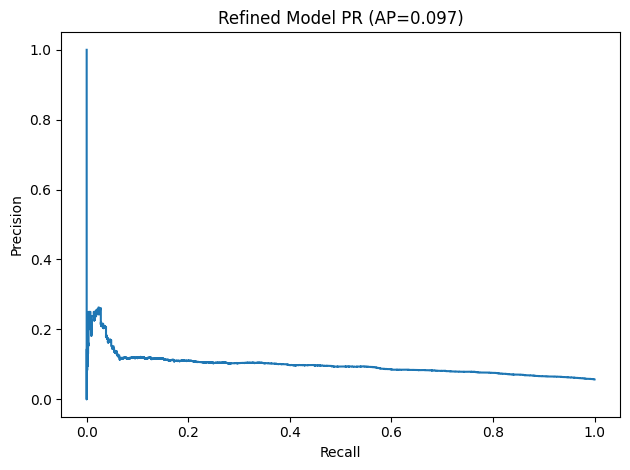

INFO: Appended refined binary metrics -> ../docs/metrics_baseline.json
INFO: Saved refined model -> ../models/refined_bin_clf.joblib


In [10]:
# Binary refinement (fresh preprocessor; XGB or HistGB)

from sklearn.model_selection import RandomizedSearchCV
from joblib import dump

X_tr = bin_train[num_feats + cat_feats]; y_tr = bin_train["abandoned_365"].astype(int).values
X_te = bin_test[num_feats + cat_feats];  y_te = bin_test["abandoned_365"].astype(int).values

pos = y_tr.sum(); neg = len(y_tr) - pos
scale_pos_weight = (neg / max(1, pos))

using_xgb = True
try:
    from xgboost import XGBClassifier
    base_clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        random_state=42,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        verbosity=1
    )
except Exception:
    using_xgb = False
    from sklearn.ensemble import HistGradientBoostingClassifier
    base_clf = HistGradientBoostingClassifier(
        max_depth=None, learning_rate=0.05, max_iter=300,
        l2_regularization=0.0, random_state=42
    )

log.info("Using estimator: %s | scale_pos_weight=%.2f",
         "XGBClassifier" if using_xgb else "HistGradientBoosting", scale_pos_weight)

pre_ref_bin = make_pre()
pipe_ref = Pipeline([("pre", pre_ref_bin), ("clf", base_clf)])

if using_xgb:
    param_distributions = {
        "clf__max_depth": [4,6,8],
        "clf__n_estimators": [300,400,600],
        "clf__learning_rate": [0.03, 0.05, 0.08],
        "clf__subsample": [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0],
        "clf__min_child_weight": [1, 5, 10],
        "clf__gamma": [0, 1],
    }
else:
    param_distributions = {
        "clf__max_depth": [None, 6, 10],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__max_iter": [200, 300, 500],
        "clf__l2_regularization": [0.0, 0.1, 1.0],
    }

log.info("Starting RandomizedSearchCV …")
rs = RandomizedSearchCV(
    pipe_ref,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2,
    error_score="raise"
)

done = timeit("RandomizedSearchCV fit (binary refined)")
rs = safe_fit(rs, X_tr, y_tr, label="RandomizedSearchCV")
done()
log.info("Best params: %s", rs.best_params_)

ref_best = rs.best_estimator_

# Predict probabilities on test
if hasattr(ref_best.named_steps["clf"], "predict_proba"):
    proba_ref = ref_best.predict_proba(X_te)[:, 1]
else:
    try:
        proba_ref = expit(ref_best.decision_function(X_te))
    except Exception:
        proba_ref = ref_best.predict_proba(X_te)

# Metrics @0.5 + best-F1
ap_ref = float(average_precision_score(y_te, proba_ref))
prec, rec, thr = precision_recall_curve(y_te, proba_ref)
thr_all = np.concatenate(([0], thr))
f1s = 2*(prec*rec)/(prec+rec+1e-12)
i_best = int(np.nanargmax(f1s))
best_thr_ref, best_f1_ref, p_at_ref, r_at_ref = float(thr_all[i_best]), float(f1s[i_best]), float(prec[i_best]), float(rec[i_best])

pred05_ref = (proba_ref >= 0.5).astype(int)
f1_05_ref  = float(f1_score(y_te, pred05_ref))
p_05_ref   = float(precision_score(y_te, pred05_ref, zero_division=0))
r_05_ref   = float(recall_score(y_te, pred05_ref, zero_division=0))

log.info("[Refined binary] AP=%.3f | @0.5: F1=%.3f P=%.3f R=%.3f", ap_ref, f1_05_ref, p_05_ref, r_05_ref)
log.info("[Refined binary] Best-F1 thr≈%.3f -> F1=%.3f P=%.3f R=%.3f", best_thr_ref, best_f1_ref, p_at_ref, r_at_ref)

# PR curve
plt.figure()
plt.step(rec, prec, where="post")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Refined Model PR (AP={ap_ref:.3f})")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/pr_curve_binary_refined.png", bbox_inches="tight")
plt.show()

# Append to metrics JSON and save refined model
with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    m = json.load(f)
m["binary_refined"] = {
    "ap": ap_ref,
    "f1_at_0.5": f1_05_ref, "precision_at_0.5": p_05_ref, "recall_at_0.5": r_05_ref,
    "best_threshold": best_thr_ref,
    "best_threshold_f1": best_f1_ref,
    "best_threshold_precision": p_at_ref,
    "best_threshold_recall": r_at_ref,
    "estimator": "XGBClassifier" if using_xgb else "HistGradientBoostingClassifier",
    "scale_pos_weight": float(scale_pos_weight)
}
with open(f"{DOCS_DIR}/metrics_baseline.json","w") as f:
    json.dump(m, f, indent=2)

dump(ref_best, f"{MODELS_DIR}/refined_bin_clf.joblib")
log.info("Appended refined binary metrics -> %s", f"{DOCS_DIR}/metrics_baseline.json")
log.info("Saved refined model -> %s", f"{MODELS_DIR}/refined_bin_clf.joblib")

In [11]:
# Multiclass refinement (fresh preprocessor; RandomForest)

mc_sub = mc_train[mc_train["abandon_reason"]!="no_return"].copy()
mc_te2 = mc_test[mc_test["abandon_reason"]!="no_return"].copy()

X_tr_m = mc_sub[num_feats + cat_feats]; y_tr_m = mc_sub["abandon_reason"].astype(str)
X_te_m = mc_te2[num_feats + cat_feats]; y_te_m = mc_te2["abandon_reason"].astype(str)

pre_rf_mc = make_pre()
rf_mc = Pipeline([
    ("pre", pre_rf_mc),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
        verbose=0
    ))
])

done = timeit("RandomForest (multiclass) fit")
rf_mc = safe_fit(rf_mc, X_tr_m, y_tr_m, label="RandomForest pipeline")
done()

y_hat_m_ref = rf_mc.predict(X_te_m)
mc_acc_ref = float(accuracy_score(y_te_m, y_hat_m_ref))
mc_f1_ref  = float(f1_score(y_te_m, y_hat_m_ref, average="macro"))
log.info("[Refined multiclass] Acc=%.3f  Macro-F1=%.3f", mc_acc_ref, mc_f1_ref)

with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    m = json.load(f)
m["multiclass_refined"] = {"accuracy": mc_acc_ref, "macro_f1": mc_f1_ref, "estimator": "RandomForest"}
with open(f"{DOCS_DIR}/metrics_baseline.json","w") as f:
    json.dump(m, f, indent=2)
log.info("Appended refined multiclass metrics -> %s", f"{DOCS_DIR}/metrics_baseline.json")

dump(mc_clf, f"{MODELS_DIR}/baseline_mc_dt.joblib")
dump(rf_mc, f"{MODELS_DIR}/refined_mc_rf.joblib")
log.info("Saved multiclass models -> %s", MODELS_DIR)

INFO: ▶ RandomForest (multiclass) fit
INFO: … fitting RandomForest pipeline on X=(10259, 6), y=10259
INFO: ✓ fit RandomForest pipeline
INFO: ✓ RandomForest (multiclass) fit (10.3s)
INFO: [Refined multiclass] Acc=0.467  Macro-F1=0.316
INFO: Appended refined multiclass metrics -> ../docs/metrics_baseline.json
INFO: Saved multiclass models -> ../models


In [12]:
# Risk bands and reason inference (drop-in)

# Load best threshold picked earlier for the binary model
with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    _m = json.load(f)
BEST_THR = float(_m["binary"]["best_threshold"])

def risk_band(score: float, thr_high: float = BEST_THR, thr_med: float = 0.35):
    """Map a probability score to a band."""
    if score >= float(thr_high):
        return "High"
    elif score >= float(thr_med):
        return "Medium"
    else:
        return "Low"

def _prep_X(rows: pd.DataFrame, train_cols):
    rows = rows.copy()

    # 1) make age_days_intake if missing useing shared parser, None -> NaN via to_numeric)
    if "age_days_intake" not in rows.columns:
        base = rows["age_upon_intake_intake"] if "age_upon_intake_intake" in rows.columns \
               else pd.Series(index=rows.index, dtype=object)
        rows["age_days_intake"] = pd.to_numeric(base.apply(parse_age_to_days), errors="coerce")

    # 2) Ensure all training columns exist, then reindex to exact order
    missing = [c for c in train_cols if c not in rows.columns]
    for c in missing:
        rows[c] = np.nan
    X = rows.reindex(columns=train_cols)

    # 3) dtypes
    if "age_days_intake" in X.columns:
        X["age_days_intake"] = pd.to_numeric(X["age_days_intake"], errors="coerce")
    for c in set(train_cols) - {"age_days_intake"}:
        X[c] = X[c].astype(object)

    return X

with open("../models/train_input_cols.json") as f:
    TRAIN_INPUT_COLS = json.load(f)

def predict_abandonment_with_band(pipeline_bin, rows: pd.DataFrame, threshold: float = BEST_THR, train_cols=None):
    """Binary risk + band."""
    if train_cols is None:
        train_cols = TRAIN_INPUT_COLS
    X = _prep_X(rows, train_cols)
    proba = pipeline_bin.predict_proba(X)[:, 1]
    labels = (proba >= float(threshold)).astype(int)
    bands = [risk_band(s, thr_high=threshold) for s in proba]
    return proba, labels, np.array(bands)

def predict_reason_if_return(pipeline_mc, rows: pd.DataFrame, train_cols=None, top_k=1):
    """Reason prediction (conditional on return)."""
    if train_cols is None:
        train_cols = TRAIN_INPUT_COLS
    X = _prep_X(rows, train_cols)
    preds = pipeline_mc.predict(X)

    topk = None
    if hasattr(pipeline_mc, "predict_proba"):
        prob = pipeline_mc.predict_proba(X)
        classes = pipeline_mc.named_steps["clf"].classes_
        topk = []
        for i in range(len(X)):
            order = np.argsort(prob[i])[::-1][:top_k]
            topk.append(list(zip(classes[order].tolist(), prob[i][order].tolist())))
    return preds, topk

# Demo on the same example row you used
example = pd.DataFrame([{
    "age_upon_intake_intake":"2 years",
    "intake_type_intake":"Owner Surrender",
    "intake_condition_intake":"Normal",
    "sex_upon_intake_intake":"Neutered Male",
    "breed_intake":"Pit Bull Mix",
    "color_intake":"Brown/White"
}])

# Binary prediction with band (uses baseline LR bin_clf)
p_bin, y_bin, bands = predict_abandonment_with_band(bin_clf, example, threshold=BEST_THR, train_cols=TRAIN_INPUT_COLS)
log.info("Binary risk = %.3f | label=%d | band=%s", float(p_bin[0]), int(y_bin[0]), bands[0])

# Reason only if predicted positive; prefer refined RF if available
reason_model = globals().get("rf_mc", None) or mc_clf
if int(y_bin[0]) == 1:
    reasons, topk = predict_reason_if_return(reason_model, example, train_cols=TRAIN_INPUT_COLS, top_k=3)
    log.info("Predicted reason: %s", reasons[0])
    if topk is not None:
        log.info("Top-3 reasons: %s", [(lab, f"{prob:.2f}") for lab, prob in topk[0]])
else:
    log.info("Predicted reason: no_return (binary model negative)")

INFO: Binary risk = 0.670 | label=1 | band=High
INFO: Predicted reason: owner_surrender
INFO: Top-3 reasons: [('owner_surrender', '0.98'), ('stray', '0.01'), ('public_assist', '0.01')]


## Benchmarks

In [13]:
# Binary majority baseline (predict 0 for everyone)
y_te_bin = bin_test["abandoned_365"].astype(int).values
proba_maj = np.zeros_like(y_te_bin, dtype=float)
pred_maj  = np.zeros_like(y_te_bin, dtype=int)
log.info("[Binary majority] AP=%.3f  F1=%.3f  P=%.3f  R=%.3f",
         average_precision_score(y_te_bin, proba_maj),
         f1_score(y_te_bin, pred_maj),
         precision_score(y_te_bin, pred_maj, zero_division=0),
         recall_score(y_te_bin, pred_maj))

INFO: [Binary majority] AP=0.057  F1=0.000  P=0.000  R=0.000


In [14]:
# Multiclass stratified guess (sample from train distribution)
rng = np.random.default_rng(42)
mc_sub = mc_train[mc_train["abandon_reason"]!="no_return"].copy()
mc_te2 = mc_test[mc_test["abandon_reason"]!="no_return"].copy()

dist = collections.Counter(mc_sub["abandon_reason"].astype(str))
labels = np.array(list(dist.keys()))
probs  = np.array([dist[k] for k in labels], dtype=float); probs /= probs.sum()

y_te_m = mc_te2["abandon_reason"].astype(str).values
pred_rand = rng.choice(labels, size=len(y_te_m), p=probs)
log.info("[Multiclass stratified] Acc=%.3f  Macro-F1=%.3f",
         accuracy_score(y_te_m, pred_rand),
         f1_score(y_te_m, pred_rand, average="macro"))

INFO: [Multiclass stratified] Acc=0.342  Macro-F1=0.225


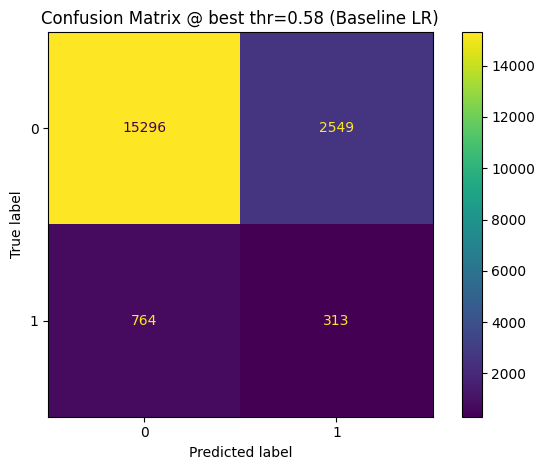

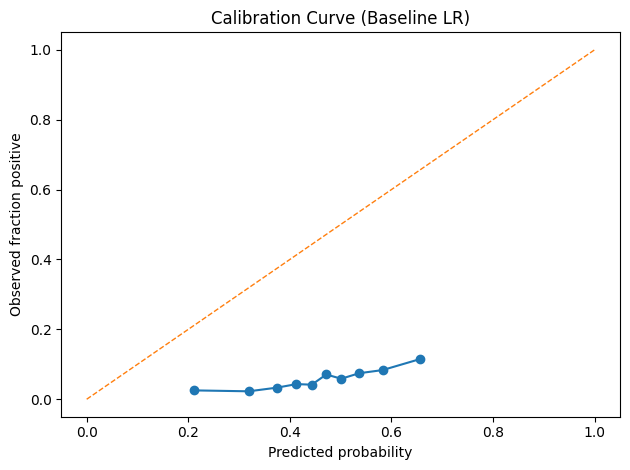

In [15]:
# Confusion matrix at best-F1 threshold (binary)

with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    _m = json.load(f)
best_thr = float(_m["binary"]["best_threshold"])

# 'proba' and (y_te) are from the baseline LR cell
pred_best = (proba >= best_thr).astype(int)
cm = confusion_matrix(y_te, pred_best, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title(f"Confusion Matrix @ best thr={best_thr:.2f} (Baseline LR)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/cm_binary_bestthr.png", bbox_inches="tight"); plt.show()

# Calibration curve (baseline LR)
prob_true, prob_pred = calibration_curve(y_te, proba, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--", linewidth=1)
plt.xlabel("Predicted probability"); plt.ylabel("Observed fraction positive")
plt.title("Calibration Curve (Baseline LR)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/calibration_binary.png", bbox_inches="tight"); plt.show()

In [16]:
# Comparison table: baseline vs refined saved to docs

with open(f"{DOCS_DIR}/metrics_baseline.json") as f:
    mm = json.load(f)

rows = []
# binary baseline @0.5 and @best
rows.append(["binary_baseline@0.5", "LogReg", mm["binary"]["pr_auc"], mm["binary"]["f1"], mm["binary"]["precision"], mm["binary"]["recall"]])
rows.append(["binary_baseline@best", "LogReg", mm["binary"]["pr_auc"],
             mm["binary"]["best_threshold_f1"], mm["binary"]["best_threshold_precision"], mm["binary"]["best_threshold_recall"]])

# refined binary (if present)
rb = mm.get("binary_refined", {})
if rb:
    rows.append(["binary_refined@0.5", rb.get("estimator"), rb.get("ap"), rb.get("f1_at_0.5"),
                 rb.get("precision_at_0.5"), rb.get("recall_at_0.5")])
    rows.append(["binary_refined@best", rb.get("estimator"), rb.get("ap"), rb.get("best_threshold_f1"),
                 rb.get("best_threshold_precision"), rb.get("best_threshold_recall")])

# multiclass baseline + refined (Macro-F1 in F1 column)
rows.append(["multiclass_baseline", "DecisionTree", None, mm["multiclass"]["macro_f1"], None, None])
mr = mm.get("multiclass_refined", {})
if mr:
    rows.append(["multiclass_refined", mr.get("estimator"), None, mr.get("macro_f1"), None, None])

comp = pd.DataFrame(rows, columns=["model","estimator","PR_AUC","F1","Precision","Recall"])


display(comp)
comp.to_csv(f"{DOCS_DIR}/metrics_comparison.csv", index=False)
log.info("Saved -> %s", f"{DOCS_DIR}/metrics_comparison.csv")

,model,estimator,PR_AUC,F1,Precision,Recall
0,binary_baseline@0.5,LogReg,0.099290,0.149038,0.086559,0.535747
1,binary_baseline@best,LogReg,0.099290,0.158964,0.109402,0.290622
2,binary_refined@0.5,XGBClassifier,0.097352,0.157587,0.091624,0.562674
3,binary_refined@best,XGBClassifier,0.097352,0.160927,0.098236,0.444754
4,multiclass_baseline,DecisionTree,NaN,0.387369,NaN,NaN
5,multiclass_refined,RandomForest,NaN,0.315998,NaN,NaN


INFO: Saved -> ../docs/metrics_comparison.csv


**END**